# Exercise 1: Comparing Optimizers on the Rosenbrock Function

- **Course:** PPGEEC2327, Special Topics in Intelligent Information Processing (AI applied to Geophysics), UFRN
- **Reference:** Schuster, G., 2024. *Machine Learning Methods in Geoscience*, SEG, Chapters 2 and 3

**Task:** Compare at least 3 optimizers on the Rosenbrock function, using the optimizer formulations introduced in Chapter 2 (Steepest Descent, Newton's Method) and Chapter 3 (Momentum, Adam, Conjugate Gradient, and others) of the textbook.

This notebook implements five optimizers:

1. Steepest Descent (Chapter 2): first-order method, backtracking line search
2. Newton's Method (Chapter 2): second-order method, uses the exact Hessian
3. Momentum (Chapter 3, Sutton 1986): first-order method with velocity accumulation
4. Adam (Chapter 3, Kingma & Ba 2014): adaptive per-parameter step size
5. Nonlinear Conjugate Gradient (Chapter 3, Polak-Ribière): uses conjugate search directions

All five start from the same point and are compared on iterations to convergence, trajectory shape, and robustness to their own hyperparameters.


## 1. Problem definition: the Rosenbrock function

The Rosenbrock function used in the textbook (Chapter 2, in the $N$-dimensional Newton example) is:

$$
f(w_1, w_2) = 100 (w_2 - w_1^2)^2 + (1 - w_1)^2
$$

with global minimum $f(1, 1) = 0$. Its gradient and Hessian, as given in the book, are:

$$
g = \begin{bmatrix} -400 w_1 (w_2 - w_1^2) - 2(1 - w_1) \\ 200 (w_2 - w_1^2) \end{bmatrix}, \qquad
H = \begin{bmatrix} 1200 w_1^2 - 400 w_2 + 2 & -400 w_1 \\ -400 w_1 & 200 \end{bmatrix}
$$

The function traces a long, curved, narrow valley. Once a search reaches the valley floor, moving further toward the minimum requires the direction to keep bending with the curve, and the gradient along that direction gets small quickly, so any method that ignores curvature tends to slow to a crawl there.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

def rosenbrock(w):
    w1, w2 = w
    return 100.0 * (w2 - w1**2)**2 + (1.0 - w1)**2

def rosenbrock_grad(w):
    w1, w2 = w
    g1 = -400.0 * w1 * (w2 - w1**2) - 2.0 * (1.0 - w1)
    g2 = 200.0 * (w2 - w1**2)
    return np.array([g1, g2])

def rosenbrock_hess(w):
    w1, w2 = w
    h11 = 1200.0 * w1**2 - 400.0 * w2 + 2.0
    h12 = -400.0 * w1
    h22 = 200.0
    return np.array([[h11, h12], [h12, h22]])

W_STAR = np.array([1.0, 1.0])
W0 = np.array([-1.2, 1.0])  # classic Rosenbrock starting point

print("f(w*) =", rosenbrock(W_STAR))
print("f(w0) =", rosenbrock(W0))
print("grad(w*) =", rosenbrock_grad(W_STAR))


f(w*) = 0.0
f(w0) = 24.199999999999996
grad(w*) = [-0.  0.]


## 2. Contour of the objective function

The plot below shows the curved valley that makes this function hard for gradient-based methods.

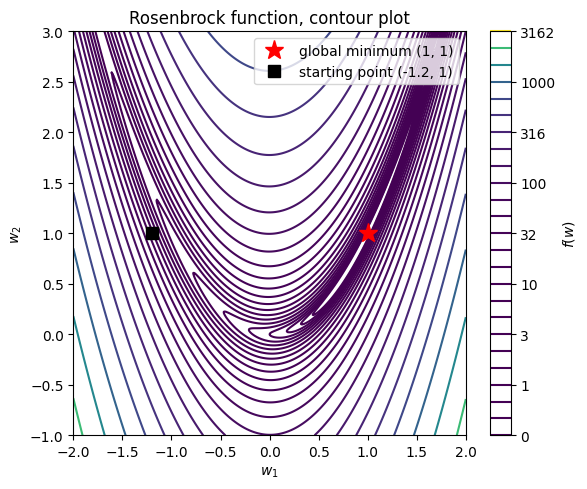

In [2]:
x1 = np.linspace(-2, 2, 400)
x2 = np.linspace(-1, 3, 400)
X1, X2 = np.meshgrid(x1, x2)
Z = 100.0 * (X2 - X1**2)**2 + (1.0 - X1)**2

fig, ax = plt.subplots(figsize=(6, 5))
cs = ax.contour(X1, X2, Z, levels=np.logspace(-0.5, 3.5, 25), cmap="viridis")
ax.plot(*W_STAR, "r*", markersize=14, label="global minimum (1, 1)")
ax.plot(*W0, "ks", markersize=8, label="starting point (-1.2, 1)")
ax.set_xlabel("$w_1$")
ax.set_ylabel("$w_2$")
ax.set_title("Rosenbrock function, contour plot")
ax.legend()
fig.colorbar(cs, ax=ax, label="$f(w)$")
plt.tight_layout()
plt.show()


## 3. Optimizer implementations (Chapters 2 and 3)

A shared backtracking (Armijo) line search stands in wherever the book relies on a step length "obtained by bisection backtracking" instead of the closed-form exact step that only applies to quadratic (linear least-squares) problems.

### 3.1 Steepest Descent (Chapter 2)

$$
w^{(k+1)} = w^{(k)} - \alpha^{(k)} \, g^{(k)}
$$

### 3.2 Newton's Method (Chapter 2)

$$
w^{(k+1)} = w^{(k)} - \left[H^{(k)}\right]^{-1} g^{(k)}
$$

### 3.3 Momentum (Chapter 3, Sutton 1986)

$$
v^{(k)} = \beta \, v^{(k-1)} + \alpha \, g^{(k)}, \qquad w^{(k+1)} = w^{(k)} - v^{(k)}
$$

### 3.4 Adam (Chapter 3, Kingma & Ba 2014)

$$
m^{(k)} = \beta_1 m^{(k-1)} + (1-\beta_1) g^{(k)}, \qquad
\sigma^{2(k)} = \beta_2 \sigma^{2(k-1)} + (1-\beta_2) (g^{(k)})^2
$$
$$
\hat m^{(k)} = \frac{m^{(k)}}{1-\beta_1^k}, \qquad \hat\sigma^{2(k)} = \frac{\sigma^{2(k)}}{1-\beta_2^k}, \qquad
w^{(k+1)}_i = w^{(k)}_i - \frac{\alpha}{\sqrt{\hat\sigma^{2(k)}_i}+\eta} \hat m^{(k)}_i
$$

### 3.5 Nonlinear Conjugate Gradient: Polak-Ribière (Chapter 3)

$$
\Delta w^{(k+1)} = -g^{(k+1)} + \beta \, \Delta w^{(k)}, \qquad
\beta = \frac{\left(g^{(k+1)}-g^{(k)}\right)^{T} g^{(k+1)}}{\left(g^{(k)}\right)^{T} g^{(k)}}
$$

$\beta$ is clipped at zero (restarting to steepest descent) whenever it goes negative, since conjugacy between directions degrades on a non-quadratic function like this one.


In [3]:
def backtracking_line_search(f, w, direction, grad, alpha0=1.0, rho=0.5, c=1e-4, max_ls=50):
    # Armijo backtracking line search (bisection), as suggested in Chapter 3.
    alpha = alpha0
    f0 = f(w)
    slope = grad @ direction
    for _ in range(max_ls):
        if f(w + alpha * direction) <= f0 + c * alpha * slope:
            return alpha
        alpha *= rho
    return alpha


In [4]:
def steepest_descent(f, grad_f, w0, tol=1e-6, max_iter=50000):
    # Chapter 2: steepest descent with backtracking line search.
    w = w0.copy()
    history = [w.copy()]
    for k in range(max_iter):
        g = grad_f(w)
        if np.linalg.norm(g) < tol:
            break
        d = -g
        alpha = backtracking_line_search(f, w, d, g)
        w = w + alpha * d
        history.append(w.copy())
    return w, np.array(history), k + 1


In [5]:
def newton(f, grad_f, hess_f, w0, tol=1e-6, max_iter=200):
    # Chapter 2: Newton's method with a Hessian solve at each step.
    w = w0.copy()
    history = [w.copy()]
    for k in range(max_iter):
        g = grad_f(w)
        if np.linalg.norm(g) < tol:
            break
        H = hess_f(w)
        try:
            d = -np.linalg.solve(H, g)
        except np.linalg.LinAlgError:
            d = -g
        if d @ g > 0:  # safeguard: fall back to steepest descent if H is not PD
            d = -g
        alpha = backtracking_line_search(f, w, d, g)
        w = w + alpha * d
        history.append(w.copy())
    return w, np.array(history), k + 1


In [6]:
def momentum(f, grad_f, w0, alpha=1e-3, beta=0.9, tol=1e-6, max_iter=50000):
    # Chapter 3: classical momentum (Sutton, 1986).
    w = w0.copy()
    v = np.zeros_like(w)
    history = [w.copy()]
    for k in range(max_iter):
        g = grad_f(w)
        if np.linalg.norm(g) < tol:
            break
        v = beta * v + alpha * g
        w = w - v
        history.append(w.copy())
    return w, np.array(history), k + 1


In [7]:
def adam(f, grad_f, w0, alpha=1e-3, beta1=0.9, beta2=0.99, eta=1e-8, tol=1e-6, max_iter=50000):
    # Chapter 3: Adam (Kingma & Ba, 2014).
    w = w0.copy()
    m = np.zeros_like(w)
    s = np.zeros_like(w)
    history = [w.copy()]
    for k in range(1, max_iter + 1):
        g = grad_f(w)
        if np.linalg.norm(g) < tol:
            break
        m = beta1 * m + (1 - beta1) * g
        s = beta2 * s + (1 - beta2) * g**2
        mh = m / (1 - beta1**k)
        sh = s / (1 - beta2**k)
        w = w - alpha * mh / (np.sqrt(sh) + eta)
        history.append(w.copy())
    return w, np.array(history), k


In [8]:
def conjugate_gradient(f, grad_f, w0, tol=1e-6, max_iter=50000):
    # Chapter 3: nonlinear CG with the Polak-Ribiere formula and restarts.
    w = w0.copy()
    g = grad_f(w)
    d = -g
    history = [w.copy()]
    for k in range(max_iter):
        if np.linalg.norm(g) < tol:
            break
        alpha = backtracking_line_search(f, w, d, g)
        w_new = w + alpha * d
        g_new = grad_f(w_new)
        beta = max(0.0, (g_new @ (g_new - g)) / (g @ g))
        d = -g_new + beta * d
        if d @ g_new > 0:  # restart to steepest descent if conjugacy is lost
            d = -g_new
        w, g = w_new, g_new
        history.append(w.copy())
    return w, np.array(history), k + 1


## 4. Running the optimizers

All optimizers start from the same point, $w_0 = (-1.2, 1)$, the classic Rosenbrock starting guess.

In [9]:
results = {}

results["Steepest Descent"] = steepest_descent(rosenbrock, rosenbrock_grad, W0)
results["Newton"] = newton(rosenbrock, rosenbrock_grad, rosenbrock_hess, W0)
results["Momentum"] = momentum(rosenbrock, rosenbrock_grad, W0, alpha=1e-3, beta=0.9)
results["Adam"] = adam(rosenbrock, rosenbrock_grad, W0, alpha=1e-3)
results["Conjugate Gradient"] = conjugate_gradient(rosenbrock, rosenbrock_grad, W0)

for name, (w, hist, iters) in results.items():
    print(f"{name:20s} iters={iters:6d}  w=({w[0]: .6f}, {w[1]: .6f})  "
          f"f={rosenbrock(w):.3e}  |grad|={np.linalg.norm(rosenbrock_grad(w)):.3e}")


Steepest Descent     iters= 13757  w=( 0.999999,  0.999998)  f=6.120e-13  |grad|=9.833e-07
Newton               iters=    22  w=( 1.000000,  1.000000)  f=3.744e-21  |grad|=4.473e-10
Momentum             iters=  3021  w=( 0.999999,  0.999998)  f=1.248e-12  |grad|=9.985e-07
Adam                 iters= 15978  w=( 1.000000,  0.999999)  f=1.689e-13  |grad|=3.745e-07
Conjugate Gradient   iters=  1125  w=( 1.000000,  1.000000)  f=4.613e-14  |grad|=9.612e-07


## 5. Results

### 5.1 Summary table

In [10]:
import pandas as pd

rows = []
for name, (w, hist, iters) in results.items():
    rows.append({
        "Optimizer": name,
        "Iterations": iters,
        "w1": w[0],
        "w2": w[1],
        "f(w)": rosenbrock(w),
        "||grad||": np.linalg.norm(rosenbrock_grad(w)),
        "Converged (tol=1e-6)": np.linalg.norm(rosenbrock_grad(w)) < 1e-6,
    })

summary = pd.DataFrame(rows).sort_values("Iterations").reset_index(drop=True)
summary


,Optimizer,Iterations,w1,w2,f(w),||grad||,Converged (tol=1e-6)
0,Newton,22,1.000000,1.000000,3.743976e-21,4.473328e-10,True
1,Conjugate Gradient,1125,1.000000,1.000000,4.613307e-14,9.611892e-07,True
2,Momentum,3021,0.999999,0.999998,1.248244e-12,9.984995e-07,True
3,Steepest Descent,13757,0.999999,0.999998,6.120022e-13,9.833371e-07,True
4,Adam,15978,1.000000,0.999999,1.689077e-13,3.745289e-07,True


### 5.2 Convergence curves

Objective value per iteration, log scale, for every optimizer.

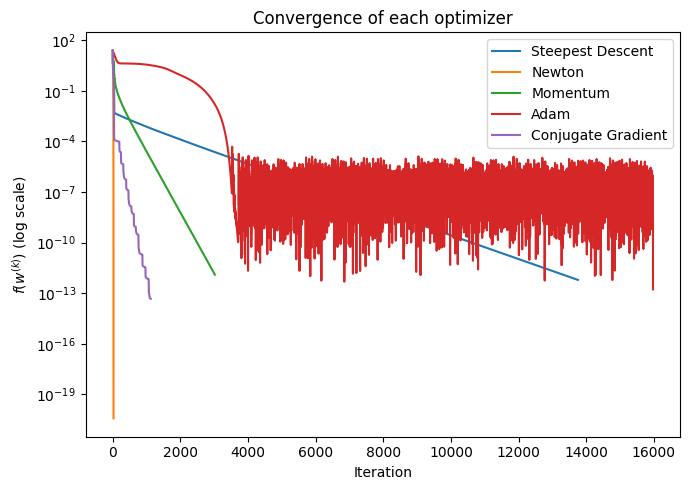

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
for name, (w, hist, iters) in results.items():
    f_vals = np.array([rosenbrock(hk) for hk in hist])
    ax.plot(f_vals, label=name)
ax.set_yscale("log")
ax.set_xlabel("Iteration")
ax.set_ylabel("$f(w^{(k)})$ (log scale)")
ax.set_title("Convergence of each optimizer")
ax.legend()
plt.tight_layout()
plt.show()


### 5.3 Trajectories on the contour plot

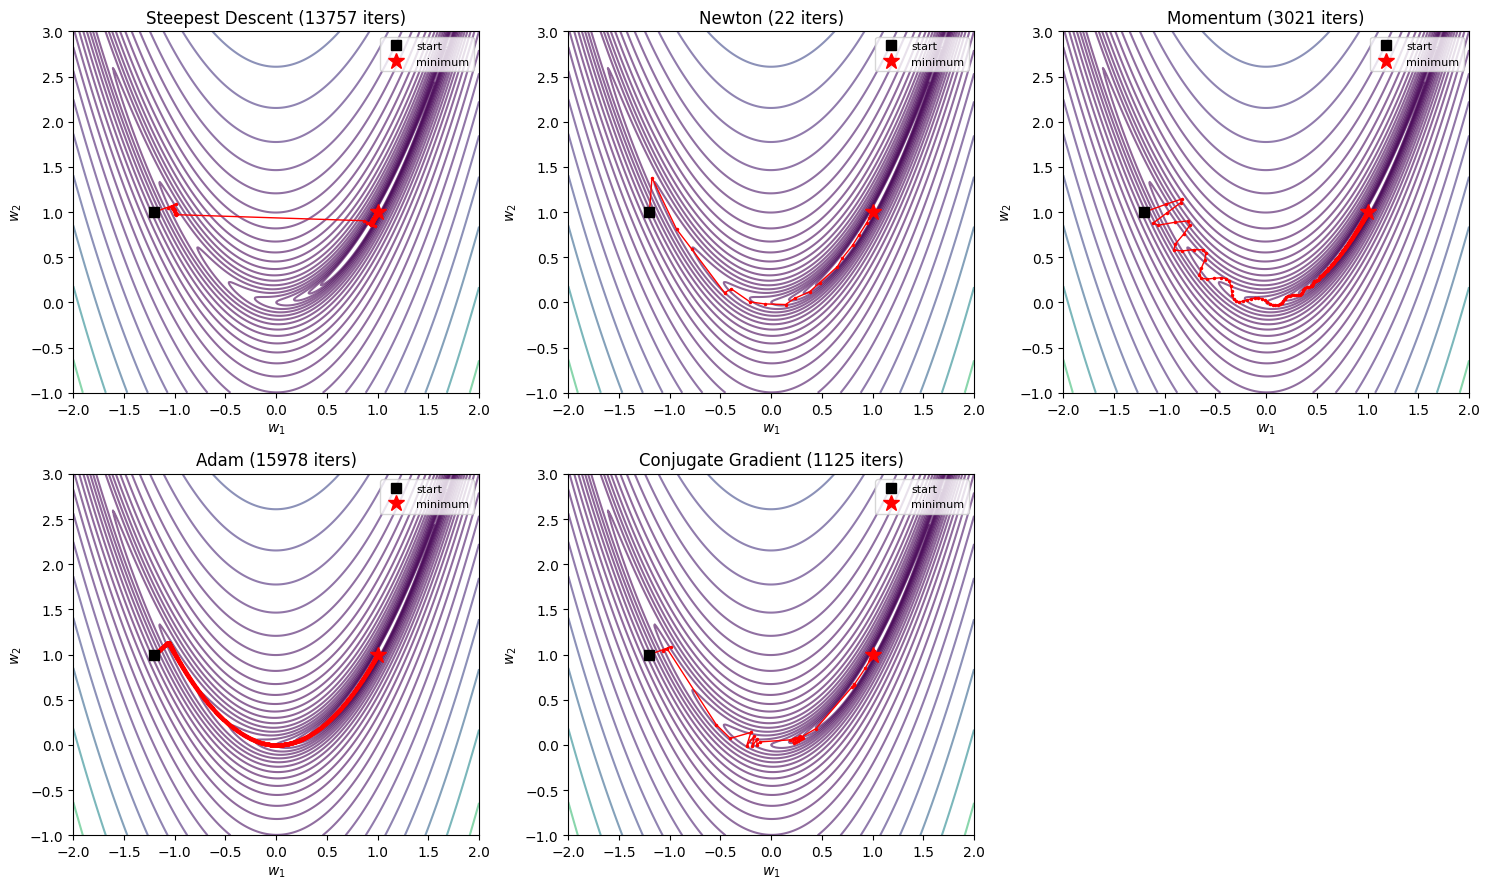

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

for ax, (name, (w, hist, iters)) in zip(axes, results.items()):
    cs = ax.contour(X1, X2, Z, levels=np.logspace(-0.5, 3.5, 25), cmap="viridis", alpha=0.6)
    ax.plot(hist[:, 0], hist[:, 1], "r.-", markersize=3, linewidth=1)
    ax.plot(*W0, "ks", markersize=7, label="start")
    ax.plot(*W_STAR, "r*", markersize=12, label="minimum")
    ax.set_title(f"{name} ({iters} iters)")
    ax.set_xlabel("$w_1$")
    ax.set_ylabel("$w_2$")
    ax.legend(fontsize=8)

axes[-1].axis("off")
plt.tight_layout()
plt.show()


### 5.4 Sensitivity analysis: Adam's step size

Of the five methods, Adam is the most sensitive to its step size $\alpha$ on this deterministic, ill-conditioned problem. Adam was built for noisy stochastic gradients, not exact ones, and the sweep below over $\alpha$ shows what that costs in the noise-free case: pushed too high, it oscillates instead of converging.

In [13]:
alphas = [1e-3, 3e-3, 5e-3, 1e-2, 2e-2]
sensitivity_rows = []
for a in alphas:
    w, hist, iters = adam(rosenbrock, rosenbrock_grad, W0, alpha=a, max_iter=100000)
    sensitivity_rows.append({
        "alpha": a,
        "iterations": iters,
        "f(w)": rosenbrock(w),
        "||grad||": np.linalg.norm(rosenbrock_grad(w)),
        "converged": np.linalg.norm(rosenbrock_grad(w)) < 1e-6,
    })

sensitivity = pd.DataFrame(sensitivity_rows)
sensitivity


,alpha,iterations,f(w),||grad||,converged
0,0.001,15978,1.689077e-13,3.745289e-07,True
1,0.003,100000,1.943503e-06,6.239293e-02,False
2,0.005,100000,1.129757e-05,1.504409e-01,False
3,0.010,100000,1.852214e-05,1.925914e-01,False
4,0.020,100000,7.582464e-08,9.479757e-03,False


## 6. Analysis and discussion

#### Newton's method

Converges in only 22 iterations, far ahead of everything else tested, because it uses the exact Hessian to account for the valley's curvature at every step. That lines up with the chapter's own summary, which rates Newton as the best-performing of the nine methods it covers precisely because it is the only one using second-order information. The cost, which the chapter also flags, is $O(N^3)$ per step to form and solve the Hessian system: irrelevant here with only two parameters, but not something you could afford for a network with millions of weights, which is why Chapter 3 spends most of its time on cheaper first-order methods instead.

#### Steepest descent

Is the slowest of the five, needing 13,757 iterations. The trajectory data shows this is not a constant zig-zag: the first roughly 50 steps move quickly from the starting point $(-1.2, 1)$ into the valley, landing near $(0.93, 0.87)$ with $f$ already down to about 0.005. From there, the remaining ~13,700 iterations crawl along the nearly flat valley floor toward $(1, 1)$. Because the gradient along the valley direction is tiny and steepest descent has no way to rescale it, each backtracking step advances only a little, which is the "vales estreitos e contornos distorcidos" failure mode the chapter uses to motivate every method that follows it.

#### Momentum

Needs 3,021 iterations, under a quarter of steepest descent's count. Accumulating a velocity term along the valley floor reinforces the gradient component that keeps pointing the same way from step to step, while damping the component that flips sign, which is the effect the chapter derives from summing two consecutive gradients.

#### Conjugate gradient

Converges in 1,125 iterations, the best among the four first-order methods. Enforcing a (locally) conjugate search direction corrects the zig-zag more directly than momentum's exponential averaging. Its trajectory plot also shows a small spiral once it reaches the neighborhood of $(1, 1)$: the Polak-Ribière $\beta$ occasionally goes negative there, the method restarts to plain steepest descent for a step, and that costs it a few hundred extra iterations of fine convergence that a purely quadratic problem would not need.

#### Adam

Only converges within the iteration budget once its step size is turned down. At $\alpha = 10^{-2}$, the value suited to noisy stochastic training, it stalls: the gradient keeps oscillating and the run never reaches tolerance. Dropping $\alpha$ to $10^{-3}$ fixes that, but it still takes 15,978 iterations, the second-slowest of the five. The convergence plot also shows something none of the other methods do: $f(w)$ does not decrease monotonically. Even after entering the valley, it swings between roughly $10^{-13}$ and $10^{-2}$ for thousands of iterations before finally settling, because Adam has no line search or curvature check guaranteeing a decrease at every step, unlike steepest descent, Newton, and CG here. That matches the chapter's citation of Wilson et al. (2017): Adam's per-parameter adaptive step, an advantage when gradients are noisy, is not automatically an advantage on a smooth, deterministic objective like this one.

#### Cost per iteration

Newton (a Hessian evaluation plus a $2\times2$ solve) costs more per step than the other four (one gradient evaluation each, plus $O(N)$ bookkeeping for momentum, Adam, and CG). That extra cost is irrelevant for a two-parameter problem where Newton finishes in 22 steps, but it would dominate for the large $N$ of a neural network, which is why the textbook moves from Newton in Chapter 2 to the cheaper methods in Chapter 3.

## 7. Conclusion

On this two-parameter Rosenbrock problem, curvature information wins by a wide margin: Newton needs two orders of magnitude fewer iterations than any first-order method tested here. Among the first-order methods, conjugate gradient and momentum recover much of that efficiency without ever touching a Hessian, while Adam needs a smaller, more deliberately chosen step size than its usual defaults to converge at all on a deterministic objective. Cheap steps that ignore curvature versus expensive steps that use it: that trade-off is why the textbook spends Chapter 2 on Newton and then develops first-order alternatives in Chapter 3 for the large-scale, non-quadratic problems, like neural network training, where Newton's cost is no longer affordable.
